## Регрессия цен на квартиры (Ridge и XGBoost) — версия для Google Colab

Данные (`all_v2.csv`) загружаются с Google Drive автоматически. Внимание: файл большой, загрузка и обработка могут занять несколько минут. Задача — предсказать цену квартиры по её характеристикам. Строятся и сравниваются две модели: линейная Ridge-регрессия и градиентный бустинг XGBoost.


In [1]:
# Установка gdown и загрузка исходных данных с Google Drive.
# gdown скачивает публичный файл Google Drive по его ID.
# ID берётся из ссылки вида https://drive.google.com/file/d/<ID>/view
!pip install -q gdown
import gdown

FILE_ID = "1PPzPflexlrqruraM048JyKVhUV3_ThaE"   # all_v2.csv
file_path = "/content/all_v2.csv"
gdown.download(id=FILE_ID, output=file_path, quiet=False)
print("Файл сохранён в:", file_path)


Downloading...
From (original): https://drive.google.com/uc?id=1PPzPflexlrqruraM048JyKVhUV3_ThaE
From (redirected): https://drive.google.com/uc?id=1PPzPflexlrqruraM048JyKVhUV3_ThaE&confirm=t&uuid=e2fea063-6472-4071-bbe7-1df25439b0c7
To: /content/all_v2.csv
100%|██████████| 408M/408M [00:07<00:00, 52.3MB/s]

Файл сохранён в: /content/all_v2.csv


В задаче регрессии мы строим модель предсказания целевого признака исходя из других признаков. Все эти признаки должны быть предствалены в числовом виде, чтобы машина могла их обработать.

Идём по плану практической работы шак за шагом.

In [2]:
# ЗАДАЧА: предсказать цену квартиры (price). Это регрессия - целевая переменная числовая.
# Этот шаг - подготовка данных:
#   1) фильтр по региону (2661 - Санкт-Петербург и область);
#   2) отбор типовых квартир по площади/цене, чтобы убрать нетипичные объекты;
#   3) замена служебных значений числа комнат (-1, -2) на 0 (студии);
#   4) новые признаки: этаж/этажность, первый и последний этаж, доля кухни,
#      давность объявления в днях.
# Промежуточные результаты сохраняем в /content, чтобы следующие ячейки их читали.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

print("Начинаем обработку датасета...")

# 1. Импорт датасета и фильтрация по региону
print("Импортируем датасет...")
df = pd.read_csv("/content/all_v2.csv")
print(f"Исходный размер датасета: {df.shape}")

# Фильтрация по региону 2661 – Санкт-Петербург и область
print("Фильтруем по региону Санкт-Петербург и область...")
df_spb = df[df['region'] == 2661].copy()
print(f"После фильтрации по региону: {df_spb.shape}")

# Сохраняем датасет после 1 шага
print("Сохраняем датасет после 1 шага (фильтрация по региону)...")
output_path_step1 = "/content/all_v2_step1_region_filter.csv"
df_spb.to_csv(output_path_step1, index=False)
print(f"Сохранен: {output_path_step1}")

# 2. Фильтрация типовых объектов
print("Отбираем типовые объекты...")
df_filtered = df_spb[
    (df_spb['area'] >= 20) & (df_spb['area'] <= 200) &
    (df_spb['kitchen_area'] >= 6) & (df_spb['kitchen_area'] <= 30) &
    (df_spb['price'] >= 1500000) & (df_spb['price'] <= 50000000)
].copy()
print(f"После фильтрации типовых объектов: {df_filtered.shape}")

# Сохраняем датасет после 2 шага
print("Сохраняем датасет после 2 шага (типовые объекты)...")
output_path_step2 = "/content/all_v2_step2_typical_objects.csv"
df_filtered.to_csv(output_path_step2, index=False)
print(f"Сохранен: {output_path_step2}")

# 3. Замена числа комнат -1 и -2 на 0
print("Заменяем специальные значения комнат...")
rooms_before = df_filtered['rooms'].value_counts().to_dict()
df_filtered['rooms'] = df_filtered['rooms'].replace([-1, -2], 0)
print(f"Значения комнат до замены: {rooms_before}")
print(f"Уникальные значения комнат после замены: {sorted(df_filtered['rooms'].unique())}")

# 4. Добавление новых признаков
print("Создаем новые признаки...")

# Этаж квартиры/Этажность
df_filtered['floor_to_total'] = df_filtered['level'] / df_filtered['levels'].where(df_filtered['levels'] > 0, np.nan)
print("Создан признак: Этаж/Этажность")

# Первый этаж
df_filtered['is_first_floor'] = (df_filtered['level'] == 1).astype(int)
print("Создан признак: Первый этаж")

# Последний этаж
df_filtered['is_last_floor'] = (df_filtered['level'] == df_filtered['levels']).astype(int)
print("Создан признак: Последний этаж")

# ratio = (S кухни/S общая)
df_filtered['kitchen_to_total_ratio'] = np.where(
    df_filtered['rooms'] == 0,
    df_filtered['area'],  # Если комнат 0, то ratio = S общая
    df_filtered['kitchen_area'] / df_filtered['area']  # Иначе отношение площадей
)
print("Создан признак: Ratio (кухня/общая)")

# 5. Добавление признака "Давность объявления"
print("Создаем признак давности объявления...")

# Преобразуем дату в datetime
df_filtered['date'] = pd.to_datetime(df_filtered['date'])
print(f"Диапазон дат: {df_filtered['date'].min().date()} - {df_filtered['date'].max().date()}")

# Находим последнюю дату в датасете
last_date = df_filtered['date'].max()
print(f"Последняя дата в датасете: {last_date.date()}")

# Вычисляем давность объявления в днях
df_filtered['days_old'] = (last_date - df_filtered['date']).dt.days
print("⏳ Создан признак: Days old (давность объявления)")

# 6. Сохранение финального обработанного датасета
print("Сохраняем финальный обработанный датасет...")
output_path_final = "/content/all_v2_processed.csv"
df_filtered.to_csv(output_path_final, index=False)
print(f"Финальный датасет сохранен: {output_path_final}")

# 7. Вывод статистики
print("\n" + "="*60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("="*60)
print(f"Финальный размер датасета: {df_filtered.shape}")
print(f"Количество признаков: {df_filtered.shape[1]}")

print("\nСохраненные файлы:")
print(f"1⃣ После фильтрации региона: all_v2_step1_region_filter.csv")
print(f"2⃣ После отбора типовых объектов: all_v2_step2_typical_objects.csv")
print(f"3⃣ Финальный обработанный: all_v2_processed.csv")

print("\nСтатистика по новым признакам:")
print(df_filtered[['floor_to_total', 'is_first_floor', 'is_last_floor', 'kitchen_to_total_ratio', 'days_old']].describe())

print("\nРаспределение по комнатам:")
print(df_filtered['rooms'].value_counts().sort_index())

print("\nРаспределение давности объявлений:")
print(f"Минимальная давность: {df_filtered['days_old'].min()} дней")
print(f"Максимальная давность: {df_filtered['days_old'].max()} дней")
print(f"Средняя давность: {df_filtered['days_old'].mean():.1f} дней")

print("\nПроверка диапазонов фильтрации:")
print(f"Площадь: {df_filtered['area'].min():.1f} - {df_filtered['area'].max():.1f} кв.м.")
print(f"Площадь кухни: {df_filtered['kitchen_area'].min():.1f} - {df_filtered['kitchen_area'].max():.1f} кв.м.")
print(f"Цена: {df_filtered['price'].min():,.0f} - {df_filtered['price'].max():,.0f} руб.")

print("\nОбработка датасета завершена успешно!")

Начинаем обработку датасета...
Импортируем датасет...
Исходный размер датасета: (5477006, 13)
Фильтруем по региону Санкт-Петербург и область...
После фильтрации по региону: (461820, 13)
Сохраняем датасет после 1 шага (фильтрация по региону)...
Сохранен: /content/all_v2_step1_region_filter.csv
Отбираем типовые объекты...
После фильтрации типовых объектов: (410663, 13)
Сохраняем датасет после 2 шага (типовые объекты)...
Сохранен: /content/all_v2_step2_typical_objects.csv
Заменяем специальные значения комнат...
Значения комнат до замены: {1: 165509, 2: 140224, 3: 84028, 4: 12713, -1: 5009, 5: 2545, 6: 426, 7: 124, 8: 42, 9: 25, -2: 18}
Уникальные значения комнат после замены: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Создаем новые признаки...
Создан признак: Этаж/Этажность
Создан признак: Первый этаж
Создан признак: Последний этаж
Создан признак: Ratio (кухня/общая)
Создаем признак давности объявления

Загружаем финальный датасет для построения матрицы корреляции...
Загружен датасет размером: (410663, 18)
Выбираем числовые признаки...
Найдено 16 числовых признаков
Вычисляем матрицу корреляции...
Создаем визуализацию матрицы корреляции...
График сохранен: /content/correlation_matrix.png


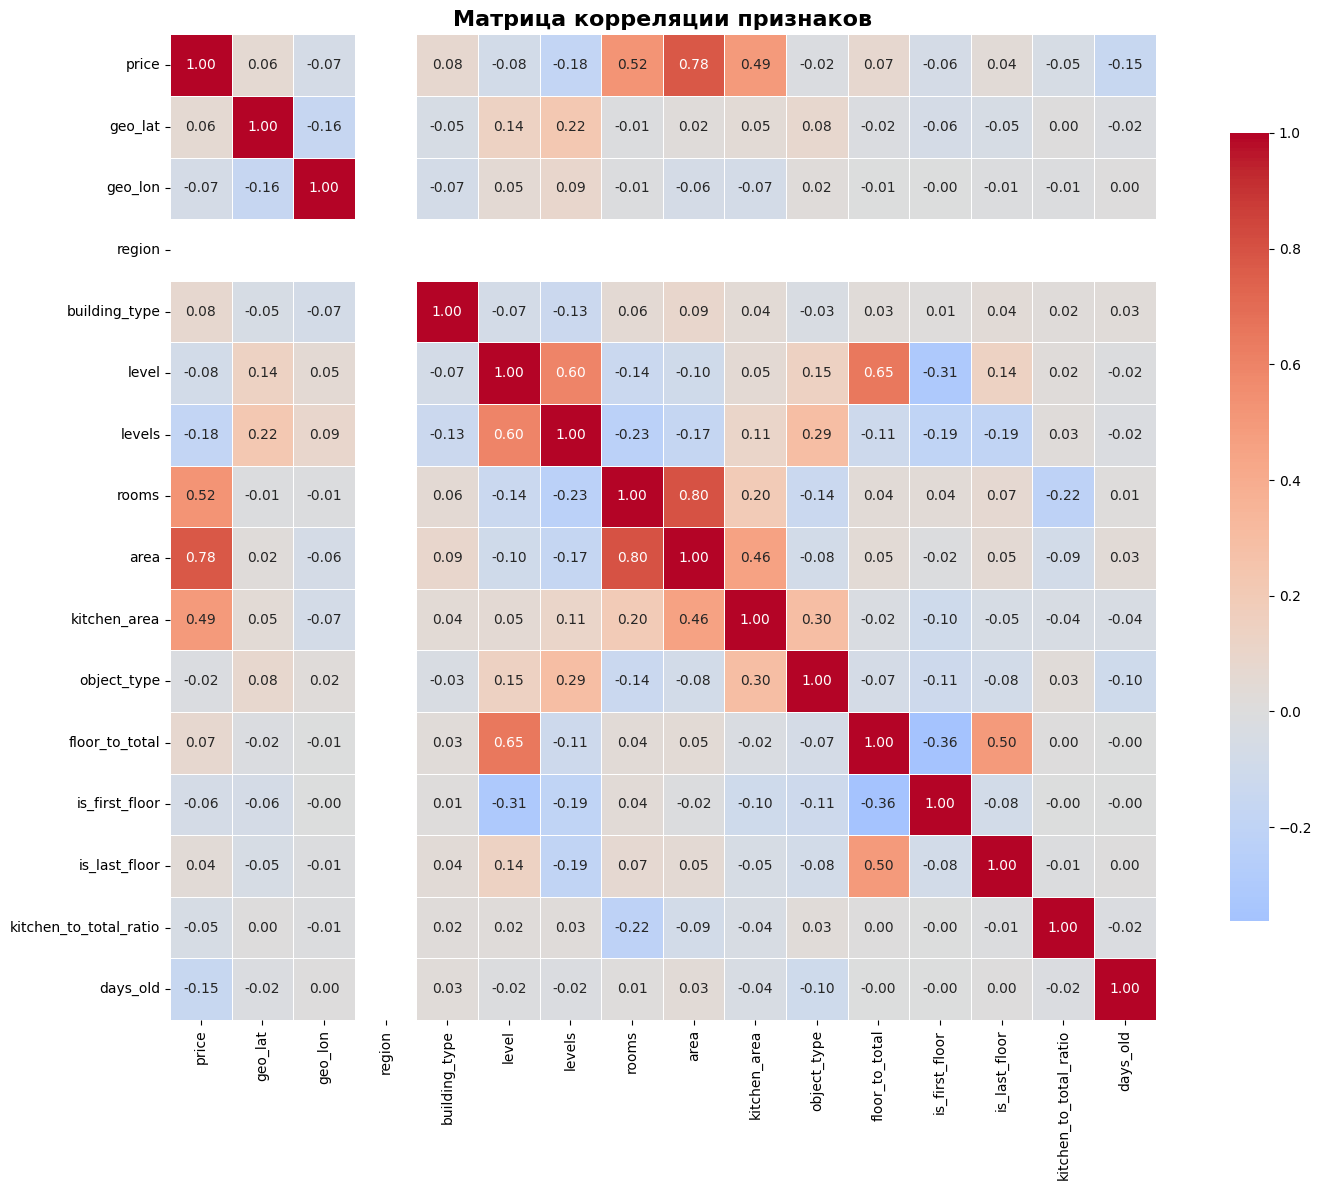


АНАЛИЗ КОРРЕЛЯЦИЙ
Найдены сильные корреляции (|r| > 0.7):
 rooms area: 0.800
 price area: 0.780

Топ-10 корреляций с ценой:
 area: 0.780
 rooms: 0.525
 kitchen_area: 0.490
 levels: -0.178
 days_old: -0.147
 building_type: 0.077
 level: -0.077
 floor_to_total: 0.074
 geo_lon: -0.069
 is_first_floor: -0.061

ПОЛНАЯ МАТРИЦА КОРРЕЛЯЦИИ
                        price  geo_lat  geo_lon  region  building_type  level  \
price                   1.000    0.060   -0.069     NaN          0.077 -0.077   
geo_lat                 0.060    1.000   -0.159     NaN         -0.047  0.137   
geo_lon                -0.069   -0.159    1.000     NaN         -0.074  0.054   
region                    NaN      NaN      NaN     NaN            NaN    NaN   
building_type           0.077   -0.047   -0.074     NaN          1.000 -0.072   
level                  -0.077    0.137    0.054     NaN         -0.072  1.000   
levels                 -0.178    0.222    0.086     NaN         -0.128  0.600   
rooms            

In [3]:
# МАТРИЦА КОРРЕЛЯЦИЙ числовых признаков.
# Корреляция показывает, насколько два признака меняются согласованно (от -1 до 1).
# Сильно скоррелированные признаки (|r| > 0.7) дублируют друг друга - это
# мультиколлинеарность, из-за неё линейная модель становится неустойчивой.
# Отдельно смотрим, какие признаки сильнее всего связаны с ценой.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

print("Загружаем финальный датасет для построения матрицы корреляции...")

# Загружаем последний обработанный датасет
df = pd.read_csv("/content/all_v2_processed.csv")
print(f"Загружен датасет размером: {df.shape}")

# Выбираем числовые признаки для корреляции
print("Выбираем числовые признаки...")
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Найдено {len(numeric_columns)} числовых признаков")

# Строим матрицу корреляции
print("Вычисляем матрицу корреляции...")
correlation_matrix = df[numeric_columns].corr()

# Визуализация матрицы корреляции
print("Создаем визуализацию матрицы корреляции...")
plt.figure(figsize=(16, 12))

# Создаем тепловую карту
sns.heatmap(correlation_matrix,
            annot=True,           # Показываем значения
            fmt='.2f',           # Формат чисел
            cmap='coolwarm',     # Цветовая схема
            center=0,            # Центр цветовой шкалы
            square=True,         # Квадратные ячейки
            linewidths=0.5,      # Линии между ячейками
            cbar_kws={"shrink": 0.8})  # Размер легенды

plt.title('Матрица корреляции признаков', fontsize=16, fontweight='bold')
plt.tight_layout()

# Сохраняем график
output_plot_path = "/content/correlation_matrix.png"
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"График сохранен: {output_plot_path}")

# Показываем график
plt.show()

# Анализ сильных корреляций
print("\n" + "="*60)
print("АНАЛИЗ КОРРЕЛЯЦИЙ")
print("="*60)

# Находим пары с сильной корреляцией (>0.7 или <-0.7)
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_corr.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': corr_value
            })

if strong_corr:
    print("Найдены сильные корреляции (|r| > 0.7):")
    for corr in sorted(strong_corr, key=lambda x: abs(x['correlation']), reverse=True):
        emoji = "" if corr['correlation'] > 0 else ""
        print(f"{emoji} {corr['feature1']} {corr['feature2']}: {corr['correlation']:.3f}")
else:
    print("Сильных корреляций не найдено")

# Топ-10 корреляций с ценой
print("\nТоп-10 корреляций с ценой:")
if 'price' in correlation_matrix.columns:
    price_corr = correlation_matrix['price'].drop('price').sort_values(key=abs, ascending=False).head(10)
    for feature, corr_value in price_corr.items():
        emoji = "" if corr_value > 0 else ""
        print(f"{emoji} {feature}: {corr_value:.3f}")
else:
    print("Признак 'price' не найден в датасете")

# Выводим полную матрицу корреляции в консоль
print("\n" + "="*60)
print("ПОЛНАЯ МАТРИЦА КОРРЕЛЯЦИИ")
print("="*60)
print(correlation_matrix.round(3))

print("\nАнализ корреляции завершен!")

In [4]:
# РАЗБИЕНИЕ на обучающую и тестовую выборки 80/20 ПО ДАТЕ (не случайно).
# Данные - это объявления во времени, поэтому честнее обучаться на прошлом и
# проверяться на будущем: train - более ранние даты, test - более поздние.
# Границу сдвигаем так, чтобы объявления с одной датой не попали сразу в обе выборки.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

print("Загружаем обработанный датасет...")
df = pd.read_csv("/content/all_v2_processed.csv")
print(f"Исходный размер: {df.shape}")

# Преобразуем дату в datetime
df['date'] = pd.to_datetime(df['date'])

# Сортируем по дате
print("Сортируем датасет по дате...")
df = df.sort_values('date').reset_index(drop=True)
print(f"Диапазон дат в датасете: {df['date'].min().date()} - {df['date'].max().date()}")

# Фильтруем по диапазону дат
print("\nФильтруем по диапазону: 2018-02-19 - 2021-05-01")
start_date = pd.to_datetime('2018-02-19')
end_date = pd.to_datetime('2021-05-01')

df_filtered = df[(df['date'] >= start_date) & (df['date'] <= end_date)].copy()
print(f"После фильтрации: {df_filtered.shape}")
print(f"Новый диапазон: {df_filtered['date'].min().date()} - {df_filtered['date'].max().date()}")

# Находим дату, которая разделит данные на 80/20 без пересечений
print("\nИщем дату для разделения без пересечений...")

# Вычисляем индекс для разделения 80/20
split_index = int(len(df_filtered) * 0.8)

# Находим дату разделения
split_date = df_filtered.iloc[split_index]['date']

# Проверяем, есть ли записи с такой же датой в обеих частях
# Если дата разделения встречается несколько раз, сдвигаем границу
# чтобы все записи с этой датой попали либо в train, либо в test

# Находим первую и последнюю позицию даты разделения
first_split_date_idx = df_filtered[df_filtered['date'] == split_date].index[0]
last_split_date_idx = df_filtered[df_filtered['date'] == split_date].index[-1]

print(f"Дата разделения: {split_date.date()}")
print(f"Записи с этой датой: с индекса {first_split_date_idx} по {last_split_date_idx}")

# Выбираем стратегию: все записи с датой разделения отправляем в train
# чтобы в test попали только более поздние даты
adjusted_split_index = last_split_date_idx + 1

train = df_filtered.iloc[:adjusted_split_index].copy()
test = df_filtered.iloc[adjusted_split_index:].copy()

# Проверяем результат
print(f"\nОбучающая выборка: {train.shape}")
print(f"   Период: {train['date'].min().date()} - {train['date'].max().date()}")
print(f"Тестовая выборка: {test.shape}")
print(f"   Период: {test['date'].min().date()} - {test['date'].max().date()}")

# Проверка на пересечения
if train['date'].max() < test['date'].min():
    print("\nПересечений по датам нет!")
    print(f"   Train заканчивается: {train['date'].max().date()}")
    print(f"   Test начинается: {test['date'].min().date()}")
else:
    print("\nОсталось пересечение по датам!")

# Финальное соотношение
ratio = len(train) / len(df_filtered)
print(f"\nФинальное соотношение train/test: {ratio:.1%} / {1-ratio:.1%}")

# Сохраняем выборки
print("\nСохраняем выборки...")
train_path = "/content/train_80.csv"
test_path = "/content/test_20.csv"

train.to_csv(train_path, index=False)
test.to_csv(test_path, index=False)

print(f"Train: {train_path}")
print(f"Test: {test_path}")
print("\nГотово!")

Загружаем обработанный датасет...
Исходный размер: (410663, 18)
Сортируем датасет по дате...
Диапазон дат в датасете: 2018-02-19 - 2021-05-01

Фильтруем по диапазону: 2018-02-19 - 2021-05-01
После фильтрации: (410663, 18)
Новый диапазон: 2018-02-19 - 2021-05-01

Ищем дату для разделения без пересечений...
Дата разделения: 2020-10-05
Записи с этой датой: с индекса 328259 по 328668

Обучающая выборка: (328669, 18)
   Период: 2018-02-19 - 2020-10-05
Тестовая выборка: (81994, 18)
   Период: 2020-10-06 - 2021-05-01

Пересечений по датам нет!
   Train заканчивается: 2020-10-05
   Test начинается: 2020-10-06

Финальное соотношение train/test: 80.0% / 20.0%

Сохраняем выборки...
Train: /content/train_80.csv
Test: /content/test_20.csv

Готово!


In [5]:
# МОДЕЛЬ 1: Ridge-регрессия (линейная регрессия с L2-регуляризацией).
# Регуляризация штрафует слишком большие коэффициенты и снижает переобучение;
# силу штрафа задаёт alpha, лучшее значение подбираем перебором через RidgeCV.
# Перед линейной моделью признаки стандартизируем (StandardScaler).
# Метрики: RMSE и MAE - ошибка в рублях (меньше лучше), R2 - доля объяснённой
# дисперсии (ближе к 1 лучше).

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

print("Загружаем обучающую и тестовую выборки...")

# Загружаем train и test
train = pd.read_csv("/content/train_80.csv")
test = pd.read_csv("/content/test_20.csv")

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

# Проверяем типы данных в train и test
print("\nПроверка типов данных в train:")
print(train.dtypes)

print("\nПроверка типов данных в test:")
print(test.dtypes)

# Находим колонки с типом object (строки)
object_columns = train.select_dtypes(include=['object']).columns.tolist()
print(f"\nНайдены строковые колонки: {object_columns}")

# Удаляем все нечисловые колонки, кроме date (если она есть)
columns_to_drop = [col for col in object_columns if col != 'date']
if columns_to_drop:
    print(f"Удаляем нечисловые колонки: {columns_to_drop}")
    train = train.drop(columns_to_drop, axis=1)
    test = test.drop(columns_to_drop, axis=1)

# Также проверяем на колонку time, если есть
if 'time' in train.columns:
    print(f"Удаляем колонку 'time': {train['time'].dtype}")
    train = train.drop('time', axis=1)
    if 'time' in test.columns:
        test = test.drop('time', axis=1)

print(f"\nTrain после очистки: {train.shape}")
print(f"Test после очистки: {test.shape}")

# Отделяем целевую переменную (price) и признаки
print("\nОтделяем целевую переменную 'price'...")

# Убираем date и price из признаков
feature_columns = [col for col in train.columns if col not in ['date', 'price']]

X_train = train[feature_columns]
y_train = train['price']

X_test = test[feature_columns]
y_test = test['price']

print(f"Признаки: {X_train.shape[1]}")
print(f"Признаки: {list(X_train.columns)}")

# Проверяем типы данных в признаках
print("\nФинальная проверка типов данных в признаках:")
print(X_train.dtypes)

# Проверяем на пропуски
print("\nПроверка на пропуски...")
print(f"Train пропуски: {X_train.isnull().sum().sum()}")
print(f"Test пропуски: {X_test.isnull().sum().sum()}")

# Заполняем пропуски медианой, если есть
if X_train.isnull().sum().sum() > 0:
    print("Заполняем пропуски медианой...")
    for col in X_train.columns:
        if X_train[col].dtype in ['float64', 'int64']:
            median_val = X_train[col].median()
            X_train[col] = X_train[col].fillna(median_val)
            X_test[col] = X_test[col].fillna(median_val)

# Стандартизация числовых признаков
print("\nСтандартизируем числовые признаки...")
scaler = StandardScaler()

# Выбираем только числовые признаки
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовых признаков: {len(numeric_columns)}")

# Проверяем, что все признаки числовые
non_numeric = [col for col in X_train.columns if col not in numeric_columns]
if non_numeric:
    print(f"Остались нечисловые признаки: {non_numeric}")
    X_train = X_train.drop(non_numeric, axis=1)
    X_test = X_test.drop(non_numeric, axis=1)
    numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

print("Стандартизация завершена")

# Проверяем на бесконечности и NaN после стандартизации
print("\nПроверка после стандартизации...")
print(f"Бесконечности в train: {np.isinf(X_train_scaled).sum().sum()}")
print(f"NaN в train: {np.isnan(X_train_scaled).sum().sum()}")

# Заменяем бесконечности на 0, если есть
X_train_scaled = X_train_scaled.replace([np.inf, -np.inf], 0)
X_test_scaled = X_test_scaled.replace([np.inf, -np.inf], 0)

# Заполняем NaN нулями, если есть
X_train_scaled = X_train_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)

# Построение модели Ridge (L2-регуляризация)
print("\nСтроим модель Ridge регрессии...")

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.alpha_
print(f"Оптимальный alpha: {best_alpha}")

# Строим финальную модель с лучшим alpha
model = Ridge(alpha=best_alpha)
model.fit(X_train_scaled, y_train)

print("Модель обучена!")

# Оценка модели на train
y_train_pred = model.predict(X_train_scaled)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Оценка модели на test
y_test_pred = model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Вывод метрик
print("\n" + "="*60)
print("МЕТРИКИ МОДЕЛИ")
print("="*60)

print("\nTRAIN:")
print(f"   MSE: {train_mse:,.0f}")
print(f"   RMSE: {train_rmse:,.0f} руб.")
print(f"   MAE: {train_mae:,.0f} руб.")
print(f"   R²: {train_r2:.4f}")

print("\nTEST:")
print(f"   MSE: {test_mse:,.0f}")
print(f"   RMSE: {test_rmse:,.0f} руб.")
print(f"   MAE: {test_mae:,.0f} руб.")
print(f"   R²: {test_r2:.4f}")

# Анализ важности признаков
print("\nТОП-10 ВАЖНЫХ ПРИЗНАКОВ:")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_,
    'abs_coef': np.abs(model.coef_)
}).sort_values('abs_coef', ascending=False)

for i, row in feature_importance.head(10).iterrows():
    direction = "" if row['coefficient'] > 0 else ""
    print(f"   {direction} {row['feature']}: {row['coefficient']:,.2f}")

# Сохраняем модель и скейлер
print("\nСохраняем модель и скейлер...")

model_path = "/content/ridge_model.pkl"
scaler_path = "/content/scaler.pkl"
features_path = "/content/model_features.txt"

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

# Сохраняем список признаков
with open(features_path, 'w') as f:
    f.write('\n'.join(X_train.columns.tolist()))

print(f"Модель сохранена: {model_path}")
print(f"Скейлер сохранен: {scaler_path}")
print(f"Список признаков сохранен: {features_path}")

print(f"\nПараметры модели:")
print(f"   Alpha (L2): {model.alpha}")
print(f"   Intercept: {model.intercept_:,.2f}")
print(f"   Количество признаков: {len(model.coef_)}")

print("\nМодель Ridge регрессии успешно построена и сохранена!")

Загружаем обучающую и тестовую выборки...
Train: (328669, 18)
Test: (81994, 18)

Проверка типов данных в train:
price                       int64
date                       object
time                       object
geo_lat                   float64
geo_lon                   float64
region                      int64
building_type               int64
level                       int64
levels                      int64
rooms                       int64
area                      float64
kitchen_area              float64
object_type                 int64
floor_to_total            float64
is_first_floor              int64
is_last_floor               int64
kitchen_to_total_ratio    float64
days_old                    int64
dtype: object

Проверка типов данных в test:
price                       int64
date                       object
time                       object
geo_lat                   float64
geo_lon                   float64
region                      int64
building_type              

In [6]:
# МОДЕЛЬ 2: XGBoost (градиентный бустинг над деревьями решений).
# Строит много деревьев последовательно, каждое исправляет ошибки предыдущих.
# Деревьям стандартизация не нужна. early_stopping_rounds останавливает обучение,
# когда качество на тесте перестаёт улучшаться (защита от переобучения).
# Метрики те же, плюс RMSLE (логарифмическая ошибка, устойчивее к большим ценам).

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error
import pickle
import xgboost as xgb

print("Загружаем обучающую и тестовую выборки...")

# Загружаем train и test
train = pd.read_csv("/content/train_80.csv")
test = pd.read_csv("/content/test_20.csv")

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

# Проверяем типы данных
print("\nПроверка типов данных...")
print(f"Строковые колонки в train: {train.select_dtypes(include=['object']).columns.tolist()}")

# Удаляем нечисловые колонки (time, date и др.)
columns_to_drop = train.select_dtypes(include=['object']).columns.tolist()
if 'date' not in columns_to_drop:
    columns_to_drop.append('date')  # дату тоже убираем из признаков

print(f"Удаляем нечисловые колонки: {columns_to_drop}")
train_clean = train.drop(columns_to_drop, axis=1)
test_clean = test.drop([col for col in columns_to_drop if col in test.columns], axis=1)

print(f"Train после очистки: {train_clean.shape}")
print(f"Test после очистки: {test_clean.shape}")

# Отделяем целевую переменную
print("\nОтделяем целевую переменную 'price'...")

X_train = train_clean.drop('price', axis=1)
y_train = train_clean['price']

X_test = test_clean.drop('price', axis=1)
y_test = test_clean['price']

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

# Проверяем на пропуски
print("\nПроверка на пропуски...")
print(f"Train пропуски: {X_train.isnull().sum().sum()}")
print(f"Test пропуски: {X_test.isnull().sum().sum()}")

# Заполняем пропуски медианой, если есть
if X_train.isnull().sum().sum() > 0:
    print("Заполняем пропуски медианой...")
    for col in X_train.columns:
        if X_train[col].dtype in ['float64', 'int64']:
            median_val = X_train[col].median()
            X_train[col] = X_train[col].fillna(median_val)
            X_test[col] = X_test[col].fillna(median_val)

# Проверяем на бесконечности
print(f"\nБесконечности в X_train: {np.isinf(X_train).sum().sum()}")
print(f"Бесконечности в X_test: {np.isinf(X_test).sum().sum()}")

X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

# Построение модели XGBoost
print("\nСтроим модель XGBoost...")

# Базовая модель XGBoost с хорошими дефолтными параметрами
model = xgb.XGBRegressor(
    n_estimators=500,          # количество деревьев
    max_depth=6,               # глубина деревьев
    learning_rate=0.1,         # скорость обучения
    subsample=0.8,             # доля данных для обучения каждого дерева
    colsample_bytree=0.8,      # доля признаков для каждого дерева
    random_state=42,
    n_jobs=-1,                 # использовать все ядра
    early_stopping_rounds=50,  # ранняя остановка
    eval_metric='rmse'
)

# Обучаем модель с валидацией на тесте для early stopping
print("Обучение модели...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

print("Модель обучена!")

# Функция для расчета RMSLE
def rmsle(y_true, y_pred):
    """Root Mean Squared Logarithmic Error"""
    # Убеждаемся, что все значения положительные
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# Предсказания
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Метрики для train
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_rmsle = rmsle(y_train, y_train_pred)

# Метрики для test
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_rmsle = rmsle(y_test, y_test_pred)

# Вывод метрик
print("\n" + "="*60)
print("МЕТРИКИ МОДЕЛИ XGBoost")
print("="*60)

print("\nTRAIN:")
print(f"   R²:    {train_r2:.4f}")
print(f"   MAE:   {train_mae:,.0f} руб.")
print(f"   RMSE:  {train_rmse:,.0f} руб.")
print(f"   RMSLE: {train_rmsle:.4f}")

print("\nTEST:")
print(f"   R²:    {test_r2:.4f}")
print(f"   MAE:   {test_mae:,.0f} руб.")
print(f"   RMSE:  {test_rmse:,.0f} руб.")
print(f"   RMSLE: {test_rmsle:.4f}")

# Сравнение train/test (проверка на переобучение)
print("\nПроверка на переобучение:")
r2_diff = train_r2 - test_r2
if r2_diff > 0.05:
    print(f"Возможно переобучение! Разница R²: {r2_diff:.4f}")
else:
    print(f"Переобучение в норме. Разница R²: {r2_diff:.4f}")

# Важность признаков
print("\nТОП-10 ВАЖНЫХ ПРИЗНАКОВ:")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# Дополнительная статистика предсказаний
print("\nСтатистика предсказаний на тесте:")
print(f"   Мин предсказание:  {y_test_pred.min():,.0f} руб.")
print(f"   Макс предсказание: {y_test_pred.max():,.0f} руб.")
print(f"   Среднее предсказание: {y_test_pred.mean():,.0f} руб.")
print(f"   Среднее реальное: {y_test.mean():,.0f} руб.")

# Сохраняем модель
print("\nСохраняем модель...")

model_path = "/content/xgboost_model.pkl"
features_path = "/content/xgboost_features.txt"

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# Сохраняем список признаков
with open(features_path, 'w') as f:
    f.write('\n'.join(X_train.columns.tolist()))

print(f"Модель сохранена: {model_path}")
print(f"Список признаков сохранен: {features_path}")

# Параметры модели
print(f"\nПараметры модели XGBoost:")
print(f"   Количество деревьев: {model.n_estimators}")
print(f"   Глубина деревьев: {model.max_depth}")
print(f"   Learning rate: {model.learning_rate}")
print(f"   Best iteration: {model.best_iteration}")

print("\nМодель XGBoost успешно построена и сохранена!")

Загружаем обучающую и тестовую выборки...
Train: (328669, 18)
Test: (81994, 18)

Проверка типов данных...
Строковые колонки в train: ['date', 'time']
Удаляем нечисловые колонки: ['date', 'time']
Train после очистки: (328669, 16)
Test после очистки: (81994, 16)

Отделяем целевую переменную 'price'...
X_train: (328669, 15)
X_test: (81994, 15)

Проверка на пропуски...
Train пропуски: 0
Test пропуски: 0

Бесконечности в X_train: 0
Бесконечности в X_test: 0

Строим модель XGBoost...
Обучение модели...
[0]	validation_0-rmse:4520741.36450	validation_1-rmse:5585164.80776
[100]	validation_0-rmse:1743414.07985	validation_1-rmse:2766131.66926
[200]	validation_0-rmse:1567106.06827	validation_1-rmse:2623011.73451
[300]	validation_0-rmse:1460086.78853	validation_1-rmse:2568760.49598
[400]	validation_0-rmse:1384470.65363	validation_1-rmse:2545950.82541
[499]	validation_0-rmse:1333811.22556	validation_1-rmse:2518668.80541
Модель обучена!

МЕТРИКИ МОДЕЛИ XGBoost

TRAIN:
   R²:    0.9250
   MAE:   739,5

Загружаем модели и данные для сравнения...
Подготовка данных...

Делаем предсказания...

СРАВНЕНИЕ МОДЕЛЕЙ: RIDGE vs XGBoost

ТАБЛИЦА МЕТРИК:
TRAIN R2     | Ridge:       0.6954 | XGBoost:       0.9250 | XGBoost
TEST R2      | Ridge:       0.6065 | XGBoost:       0.7949 | XGBoost
TRAIN MAE    | Ridge: 1565371.9071 | XGBoost:  739553.0000 | XGBoost
TEST MAE     | Ridge: 2129521.5533 | XGBoost: 1604652.3750 | XGBoost
TRAIN RMSE   | Ridge: 2688267.5692 | XGBoost: 1333811.2482 | XGBoost
TEST RMSE    | Ridge: 3489033.2691 | XGBoost: 2518668.7726 | XGBoost
TRAIN RMSLE  | Ridge:       0.5288 | XGBoost:       0.1550 | XGBoost
TEST RMSLE   | Ridge:       0.3106 | XGBoost:       0.2245 | XGBoost

ИТОГОВЫЙ ВЕРДИКТ:
Победитель: XGBoost 
XGBoost R² на тесте: 0.7949
Ridge R² на тесте: 0.6065

По MAE (средняя ошибка в рублях):
Ridge:   2,129,522 руб.
XGBoost: 1,604,652 руб.

FEATURE IMPORTANCE

RIDGE - ТОП-15 ВАЖНЫХ ПРИЗНАКОВ (по абсолютным коэффициентам):
    8. + area                           45845

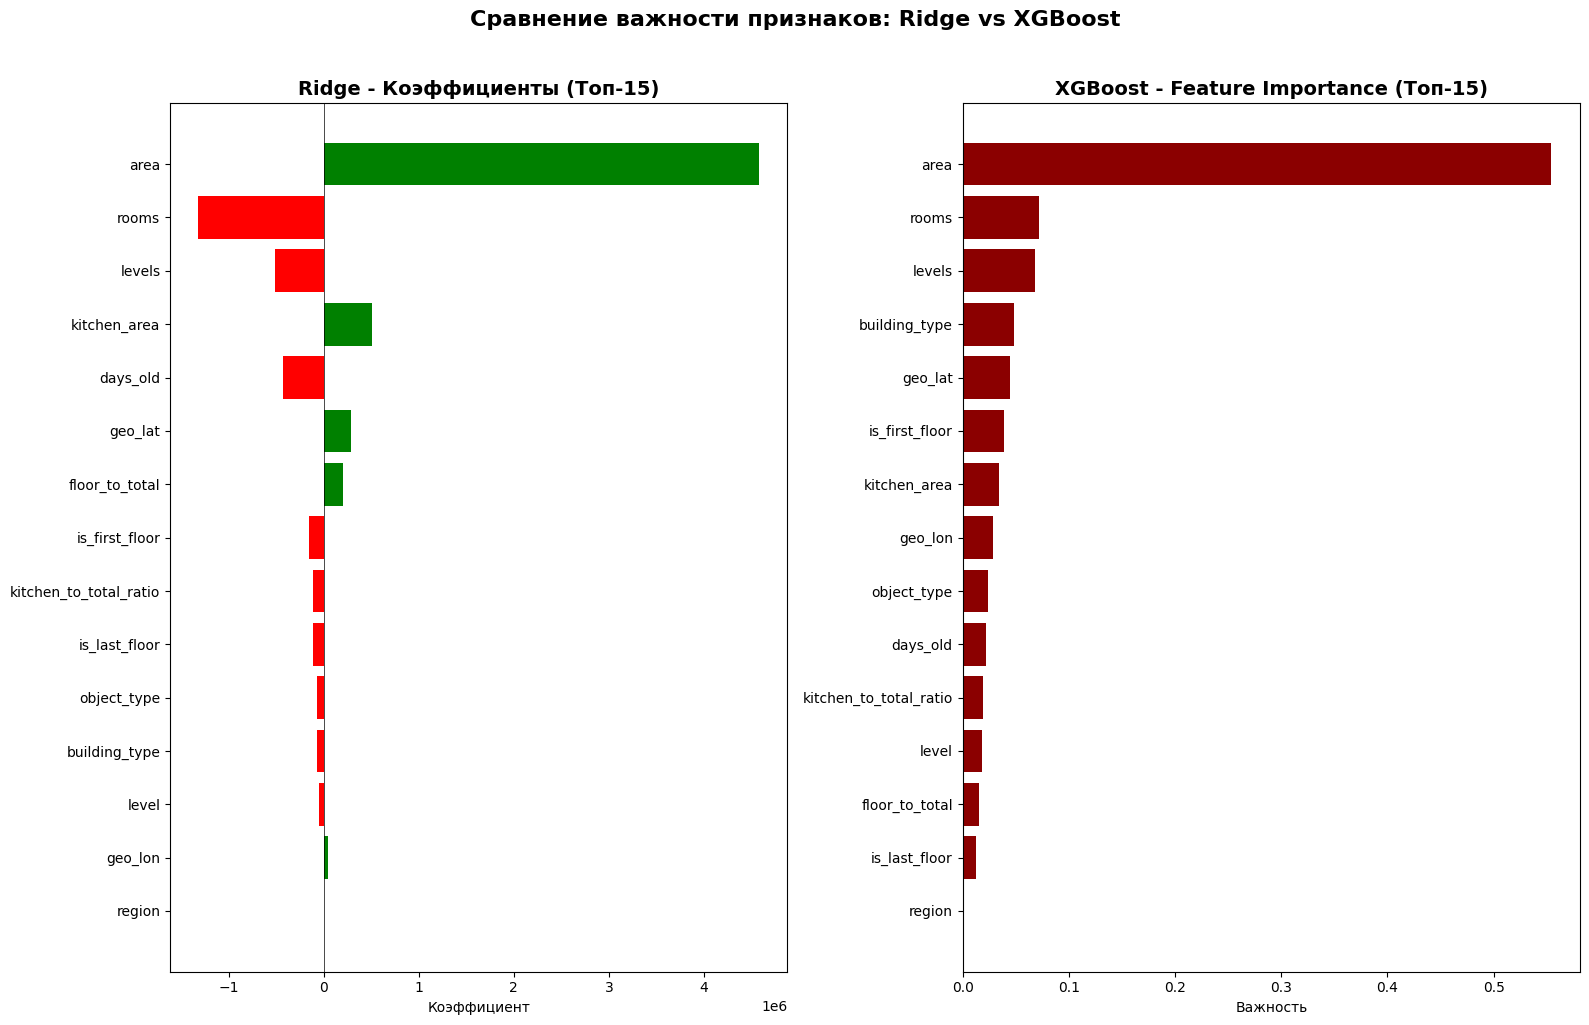


СВОДНАЯ ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ:

Топ-10 по среднему рангу важности:
   area                           | Ridge rank:   1 | XGBoost rank:   1 | Avg:   1.0
   rooms                          | Ridge rank:   2 | XGBoost rank:   2 | Avg:   2.0
   levels                         | Ridge rank:   3 | XGBoost rank:   3 | Avg:   3.0
   geo_lat                        | Ridge rank:   6 | XGBoost rank:   5 | Avg:   5.5
   kitchen_area                   | Ridge rank:   4 | XGBoost rank:   7 | Avg:   5.5
   is_first_floor                 | Ridge rank:   8 | XGBoost rank:   6 | Avg:   7.0
   days_old                       | Ridge rank:   5 | XGBoost rank:  10 | Avg:   7.5
   building_type                  | Ridge rank:  12 | XGBoost rank:   4 | Avg:   8.0
   floor_to_total                 | Ridge rank:   7 | XGBoost rank:  13 | Avg:  10.0
   kitchen_to_total_ratio         | Ridge rank:   9 | XGBoost rank:  11 | Avg:  10.0

Таблица сравнения сохранена: /content/model_comparison.csv

Сравнение моделе

In [7]:
# СРАВНЕНИЕ двух моделей (Ridge и XGBoost) на одних и тех же данных.
# Сравниваем метрики на тесте (главные - R2 и MAE) и важность признаков:
# для Ridge - по величине коэффициентов, для XGBoost - по встроенной feature importance.

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error
import pickle
import matplotlib.pyplot as plt

print("Загружаем модели и данные для сравнения...")

# Загружаем данные
train = pd.read_csv("/content/train_80.csv")
test = pd.read_csv("/content/test_20.csv")

# Загружаем модели
with open("/content/ridge_model.pkl", 'rb') as f:
    ridge_model = pickle.load(f)

with open("/content/scaler.pkl", 'rb') as f:
    scaler = pickle.load(f)

with open("/content/xgboost_model.pkl", 'rb') as f:
    xgb_model = pickle.load(f)

# Подготовка данных
print("Подготовка данных...")
columns_to_drop = train.select_dtypes(include=['object']).columns.tolist()
if 'date' not in columns_to_drop:
    columns_to_drop.append('date')

train_clean = train.drop(columns_to_drop, axis=1)
test_clean = test.drop([col for col in columns_to_drop if col in test.columns], axis=1)

X_train = train_clean.drop('price', axis=1)
y_train = train_clean['price']
X_test = test_clean.drop('price', axis=1)
y_test = test_clean['price']

# Заполняем пропуски
for col in X_train.columns:
    if X_train[col].dtype in ['float64', 'int64']:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

# Для Ridge нужна стандартизация
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Функция для расчета RMSLE
def rmsle(y_true, y_pred):
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# Предсказания
print("\nДелаем предсказания...")
ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Расчет метрик
print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ: RIDGE vs XGBoost")
print("="*70)

# Метрики для Ridge
ridge_metrics = {
    'model': 'Ridge',
    'train_r2': r2_score(y_train, ridge_train_pred),
    'test_r2': r2_score(y_test, ridge_test_pred),
    'train_mae': mean_absolute_error(y_train, ridge_train_pred),
    'test_mae': mean_absolute_error(y_test, ridge_test_pred),
    'train_rmse': np.sqrt(mean_squared_error(y_train, ridge_train_pred)),
    'test_rmse': np.sqrt(mean_squared_error(y_test, ridge_test_pred)),
    'train_rmsle': rmsle(y_train, ridge_train_pred),
    'test_rmsle': rmsle(y_test, ridge_test_pred)
}

# Метрики для XGBoost
xgb_metrics = {
    'model': 'XGBoost',
    'train_r2': r2_score(y_train, xgb_train_pred),
    'test_r2': r2_score(y_test, xgb_test_pred),
    'train_mae': mean_absolute_error(y_train, xgb_train_pred),
    'test_mae': mean_absolute_error(y_test, xgb_test_pred),
    'train_rmse': np.sqrt(mean_squared_error(y_train, xgb_train_pred)),
    'test_rmse': np.sqrt(mean_squared_error(y_test, xgb_test_pred)),
    'train_rmsle': rmsle(y_train, xgb_train_pred),
    'test_rmsle': rmsle(y_test, xgb_test_pred)
}

# Таблица сравнения
comparison_df = pd.DataFrame([ridge_metrics, xgb_metrics])
comparison_df = comparison_df.set_index('model')

print("\nТАБЛИЦА МЕТРИК:")
print("="*70)
for metric in ['train_r2', 'test_r2', 'train_mae', 'test_mae', 'train_rmse', 'test_rmse', 'train_rmsle', 'test_rmsle']:
    metric_name = metric.replace('train_', 'Train ').replace('test_', 'Test ').upper()

    ridge_val = comparison_df.loc['Ridge', metric]
    xgb_val = comparison_df.loc['XGBoost', metric]

    # Определяем победителя
    if metric in ['train_mae', 'test_mae', 'train_rmse', 'test_rmse', 'train_rmsle', 'test_rmsle']:
        # Чем меньше, тем лучше
        winner = "Ridge" if ridge_val < xgb_val else "XGBoost"
    else:
        # R2 - чем больше, тем лучше
        winner = "Ridge" if ridge_val > xgb_val else "XGBoost"

    print(f"{metric_name:12} | Ridge: {ridge_val:>12.4f} | XGBoost: {xgb_val:>12.4f} | {winner}")


# Итоговый вердикт
print("\n" + "="*70)
print("ИТОГОВЫЙ ВЕРДИКТ:")
print("="*70)

# Сравниваем по test R² (основная метрика)
if ridge_metrics['test_r2'] > xgb_metrics['test_r2']:
    print("Победитель: RIDGE ")
    print(f"Ridge R² на тесте: {ridge_metrics['test_r2']:.4f}")
    print(f"XGBoost R² на тесте: {xgb_metrics['test_r2']:.4f}")
else:
    print("Победитель: XGBoost ")
    print(f"XGBoost R² на тесте: {xgb_metrics['test_r2']:.4f}")
    print(f"Ridge R² на тесте: {ridge_metrics['test_r2']:.4f}")

# Сравнение по MAE
print(f"\nПо MAE (средняя ошибка в рублях):")
print(f"Ridge:   {ridge_metrics['test_mae']:,.0f} руб.")
print(f"XGBoost: {xgb_metrics['test_mae']:,.0f} руб.")

# Feature Importance
print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)

# Для Ridge - коэффициенты
print("\nRIDGE - ТОП-15 ВАЖНЫХ ПРИЗНАКОВ (по абсолютным коэффициентам):")
ridge_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': ridge_model.coef_,
    'abs_coef': np.abs(ridge_model.coef_)
}).sort_values('abs_coef', ascending=False)

for i, row in ridge_importance.head(15).iterrows():
    direction = "+" if row['coefficient'] > 0 else ""
    print(f"   {i+1:2}. {direction} {row['feature']:30} {row['coefficient']:>12.4f}")

# Для XGBoost - важность признаков
print("\nXGBOOST - ТОП-15 ВАЖНЫХ ПРИЗНАКОВ (по встроенной важности):")
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

for i, row in xgb_importance.head(15).iterrows():
    print(f"   {i+1:2}. {row['feature']:30} {row['importance']:>12.4f}")

# Сравнение топ-признаков
print("\nСРАВНЕНИЕ ТОП-10 ПРИЗНАКОВ:")
ridge_top10 = set(ridge_importance.head(10)['feature'].tolist())
xgb_top10 = set(xgb_importance.head(10)['feature'].tolist())

common = ridge_top10 & xgb_top10
ridge_only = ridge_top10 - xgb_top10
xgb_only = xgb_top10 - ridge_top10

print(f"Общие признаки ({len(common)}): {', '.join(sorted(common))}")
print(f"Только в Ridge ({len(ridge_only)}): {', '.join(sorted(ridge_only))}")
print(f"Только в XGBoost ({len(xgb_only)}): {', '.join(sorted(xgb_only))}")

# Визуализация сравнения feature importance
print("\nСоздаем визуализацию важности признаков...")
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Ridge
ridge_plot = ridge_importance.head(15).copy()
colors_ridge = ['green' if x > 0 else 'red' for x in ridge_plot['coefficient']]
axes[0].barh(range(len(ridge_plot)), ridge_plot['coefficient'], color=colors_ridge)
axes[0].set_yticks(range(len(ridge_plot)))
axes[0].set_yticklabels(ridge_plot['feature'])
axes[0].set_title('Ridge - Коэффициенты (Топ-15)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Коэффициент')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].invert_yaxis()

# XGBoost
xgb_plot = xgb_importance.head(15).copy()
axes[1].barh(range(len(xgb_plot)), xgb_plot['importance'], color='darkred')
axes[1].set_yticks(range(len(xgb_plot)))
axes[1].set_yticklabels(xgb_plot['feature'])
axes[1].set_title('XGBoost - Feature Importance (Топ-15)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Важность')
axes[1].invert_yaxis()

plt.suptitle('Сравнение важности признаков: Ridge vs XGBoost', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Сохраняем график
plot_path = "/content/feature_importance_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"График сохранен: {plot_path}")

# Показываем график
plt.show()

# Создаем сводную таблицу feature importance
print("\nСВОДНАЯ ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ:")
summary_df = pd.DataFrame({
    'feature': X_train.columns,
    'ridge_rank': ridge_importance['abs_coef'].rank(ascending=False),
    'ridge_coef': ridge_importance['coefficient'],
    'xgb_rank': xgb_importance['importance'].rank(ascending=False),
    'xgb_importance': xgb_importance['importance']
})
summary_df['avg_rank'] = (summary_df['ridge_rank'] + summary_df['xgb_rank']) / 2
summary_df = summary_df.sort_values('avg_rank')

print("\nТоп-10 по среднему рангу важности:")
for i, row in summary_df.head(10).iterrows():
    print(f"   {row['feature']:30} | Ridge rank: {row['ridge_rank']:3.0f} | XGBoost rank: {row['xgb_rank']:3.0f} | Avg: {row['avg_rank']:5.1f}")

# Сохраняем результаты сравнения
comparison_path = "/content/model_comparison.csv"
comparison_df.to_csv(comparison_path)
print(f"\nТаблица сравнения сохранена: {comparison_path}")

print("\nСравнение моделей завершено!")

После построения моделей нужно проверить её работу. Создаём синтетические данные и смотрим, как отрабатывают модели по этим данным.

In [8]:
# ПРОВЕРКА моделей на придуманных (синтетических) квартирах.
# Вручную задаём характеристики нескольких квартир и смотрим, какую цену предскажут
# обе модели. Это качественная проверка адекватности: дороже ли выходят большие
# квартиры в центре и т.д. Порядок признаков должен совпадать с обучением.

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error
import pickle

print("ЗАГРУЖАЕМ МОДЕЛИ И ДАННЫЕ ДЛЯ ТЕСТИРОВАНИЯ...")

# Загружаем модели
with open("/content/ridge_model.pkl", 'rb') as f:
    ridge_model = pickle.load(f)

with open("/content/scaler.pkl", 'rb') as f:
    scaler = pickle.load(f)

with open("/content/xgboost_model.pkl", 'rb') as f:
    xgb_model = pickle.load(f)

# Загружаем оригинальные данные, чтобы узнать порядок признаков
train = pd.read_csv("/content/train_80.csv")

# Удаляем те же колонки, что и при обучении
columns_to_drop = train.select_dtypes(include=['object']).columns.tolist()
if 'date' not in columns_to_drop:
    columns_to_drop.append('date')

train_clean = train.drop(columns_to_drop, axis=1)
X_train = train_clean.drop('price', axis=1)

# Получаем правильный порядок признаков
feature_order = list(X_train.columns)
print(f"Ожидаемый порядок признаков ({len(feature_order)}):")
print(f"   {feature_order}")

print("Модели загружены!")

# ============================================================================
# СИНТЕТИЧЕСКИЕ ДАННЫЕ ДЛЯ ТЕСТИРОВАНИЯ
# МЕНЯЙТЕ ЗНАЧЕНИЯ ЗДЕСЬ ДЛЯ ТЕСТИРОВАНИЯ РАЗНЫХ СЦЕНАРИЕВ
# ============================================================================

print("\n" + "="*70)
print("СОЗДАЕМ СИНТЕТИЧЕСКИЕ ДАННЫЕ ДЛЯ ТЕСТИРОВАНИЯ")
print("="*70)

# Создаем базовый словарь со всеми признаками в правильном порядке
def create_test_apartment(**kwargs):
    """Создает квартиру с дефолтными значениями, которые можно переопределить"""
    default = {
        'area': 50,
        'kitchen_area': 10,
        'rooms': 2,
        'level': 5,
        'levels': 12,
        'building_type': 1,
        'object_type': 1,
        'geo_lat': 59.9343,
        'geo_lon': 30.3351,
        'region': 2661,
        'floor_to_total': 5/12,
        'is_first_floor': 0,
        'is_last_floor': 0,
        'kitchen_to_total_ratio': 10/50,
        'days_old': 30,
    }
    default.update(kwargs)

    # Создаем словарь в правильном порядке признаков
    ordered = {}
    for feature in feature_order:
        if feature in default:
            ordered[feature] = default[feature]
        else:
            ordered[feature] = 0  # Дефолтное значение для отсутствующих признаков

    return ordered

# Создаем тестовые квартиры с разными характеристиками
test_apartments = [
    # Квартира 1: Маленькая студия в центре
    create_test_apartment(
        area=25, kitchen_area=8, rooms=0, level=5, levels=12,
        geo_lat=59.9343, geo_lon=30.3351,
        floor_to_total=5/12, kitchen_to_total_ratio=25,  # для студий ratio = общая площадь
        days_old=30, is_first_floor=0, is_last_floor=0
    ),

    # Квартира 2: Большая 3-комнатная в спальном районе
    create_test_apartment(
        area=85, kitchen_area=14, rooms=3, level=8, levels=16,
        geo_lat=59.8500, geo_lon=30.2500,
        floor_to_total=8/16, kitchen_to_total_ratio=14/85,
        days_old=60
    ),

    # Квартира 3: Элитная квартира с террасой (последний этаж)
    create_test_apartment(
        area=150, kitchen_area=25, rooms=4, level=20, levels=20,
        building_type=2, geo_lat=59.9400, geo_lon=30.3000,
        floor_to_total=20/20, kitchen_to_total_ratio=25/150,
        days_old=15, is_last_floor=1
    ),

    # Квартира 4: Дешевая квартира на первом этаже
    create_test_apartment(
        area=35, kitchen_area=7, rooms=1, level=1, levels=5,
        building_type=3, geo_lat=59.8900, geo_lon=30.4000,
        floor_to_total=1/5, kitchen_to_total_ratio=7/35,
        days_old=90, is_first_floor=1
    ),

    # Квартира 5: Средняя 2-комнатная в новостройке
    create_test_apartment(
        area=55, kitchen_area=10, rooms=2, level=10, levels=25,
        geo_lat=59.9200, geo_lon=30.3500,
        floor_to_total=10/25, kitchen_to_total_ratio=10/55,
        days_old=45
    ),

    # Квартира 6: Большая квартира в центре (пентхаус)
    create_test_apartment(
        area=180, kitchen_area=28, rooms=5, level=18, levels=18,
        building_type=2, object_type=2, geo_lat=59.9360, geo_lon=30.3100,
        floor_to_total=18/18, kitchen_to_total_ratio=28/180,
        days_old=7, is_last_floor=1
    ),

    # Квартира 7: Студия на окраине (первый этаж)
    create_test_apartment(
        area=22, kitchen_area=6, rooms=0, level=1, levels=9,
        geo_lat=59.9800, geo_lon=30.4500,
        floor_to_total=1/9, kitchen_to_total_ratio=22,  # для студий ratio = общая площадь
        days_old=120, is_first_floor=1
    ),

    # Квартира 8: Хрущевка в хорошем районе
    create_test_apartment(
        area=42, kitchen_area=7, rooms=2, level=3, levels=5,
        building_type=3, geo_lat=59.9500, geo_lon=30.2800,
        floor_to_total=3/5, kitchen_to_total_ratio=7/42,
        days_old=75
    ),
]

# Создаем DataFrame
synthetic_data = pd.DataFrame(test_apartments)

# Добавляем описательные названия
apartment_names = [
    "Студия в центре (25м²)",
    "3-к квартира в спальном районе (85м²)",
    "Элитная 4-к на последнем этаже (150м²)",
    "1-к на первом этаже в старом фонде (35м²)",
    "2-к в новостройке (55м²)",
    "Пентхаус 5-к в центре (180м²)",
    "Студия на окраине, 1 этаж (22м²)",
    "Хрущевка 2-к (42м²)",
]

synthetic_data['description'] = apartment_names

print(f"Создано {len(synthetic_data)} синтетических квартир для тестирования")
print(f"Размер данных: {synthetic_data.shape}")
print(f"Порядок признаков совпадает с обучением: ")

# ============================================================================
# ДЕЛАЕМ ПРЕДСКАЗАНИЯ
# ============================================================================

print("\n" + "="*70)
print("ПРЕДСКАЗАНИЯ ЦЕН")
print("="*70)

# Подготавливаем данные (убираем description и убеждаемся в правильном порядке)
X_synthetic = synthetic_data.drop('description', axis=1)

# Проверяем, что порядок колонок совпадает
assert list(X_synthetic.columns) == feature_order, "Порядок признаков не совпадает!"
print("Порядок признаков проверен")

# Стандартизируем для Ridge
X_synthetic_scaled = scaler.transform(X_synthetic)

# Предсказания Ridge
ridge_predictions = ridge_model.predict(X_synthetic_scaled)

# Предсказания XGBoost
xgb_predictions = xgb_model.predict(X_synthetic)

# ============================================================================
# ВЫВОД РЕЗУЛЬТАТОВ
# ============================================================================

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ")
print("="*70)

for i in range(len(synthetic_data)):
    print(f"\n{'='*70}")
    print(f"КВАРТИРА {i+1}: {apartment_names[i]}")
    print(f"{'='*70}")

    # Характеристики квартиры
    print("Характеристики:")
    print(f"   • Площадь: {synthetic_data.iloc[i]['area']} м²")
    print(f"   • Кухня: {synthetic_data.iloc[i]['kitchen_area']} м²")
    print(f"   • Комнат: {synthetic_data.iloc[i]['rooms']}")
    print(f"   • Этаж: {synthetic_data.iloc[i]['level']}/{synthetic_data.iloc[i]['levels']}")
    print(f"   • Тип здания: {synthetic_data.iloc[i]['building_type']}")
    print(f"   • Первый этаж: {'Да' if synthetic_data.iloc[i]['is_first_floor'] else 'Нет'}")
    print(f"   • Последний этаж: {'Да' if synthetic_data.iloc[i]['is_last_floor'] else 'Нет'}")
    print(f"   • Давность объявления: {synthetic_data.iloc[i]['days_old']} дн.")

    # Предсказания
    ridge_price = ridge_predictions[i]
    xgb_price = xgb_predictions[i]
    avg_price = (ridge_price + xgb_price) / 2

    print(f"\nПредсказания цены:")
    print(f"   • Ridge:     {ridge_price:>12,.0f} руб.")
    print(f"   • XGBoost:   {xgb_price:>12,.0f} руб.")
    print(f"   • Среднее:   {avg_price:>12,.0f} руб.")

    # Цена за квадратный метр
    area = synthetic_data.iloc[i]['area']
    print(f"\nЦена за м²:")
    print(f"   • Ridge:     {ridge_price/area:>10,.0f} руб./м²")
    print(f"   • XGBoost:   {xgb_price/area:>10,.0f} руб./м²")
    print(f"   • Среднее:   {avg_price/area:>10,.0f} руб./м²")

# ============================================================================
# СВОДНАЯ ТАБЛИЦА
# ============================================================================

print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА ВСЕХ ПРЕДСКАЗАНИЙ")
print("="*70)

summary = pd.DataFrame({
    'Квартира': [f"Кв.{i+1}" for i in range(len(synthetic_data))],
    'Описание': apartment_names,
    'Площадь': synthetic_data['area'],
    'Комнат': synthetic_data['rooms'],
    'Ridge (руб)': ridge_predictions.astype(int),
    'XGBoost (руб)': xgb_predictions.astype(int),
    'Среднее (руб)': ((ridge_predictions + xgb_predictions) / 2).astype(int),
    'Ridge (руб/м²)': (ridge_predictions / synthetic_data['area']).astype(int),
    'XGBoost (руб/м²)': (xgb_predictions / synthetic_data['area']).astype(int),
})

print(summary.to_string(index=False))

# ============================================================================
# АНАЛИЗ РАЗБРОСА ПРЕДСКАЗАНИЙ
# ============================================================================

print("\n" + "="*70)
print("АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ МОДЕЛЯМИ")
print("="*70)

diff = np.abs(ridge_predictions - xgb_predictions)
diff_percent = (diff / ((ridge_predictions + xgb_predictions) / 2)) * 100

for i in range(len(synthetic_data)):
    print(f"Кв.{i+1}: Разница {diff[i]:,.0f} руб. ({diff_percent[i]:.1f}%)")

print(f"\nСредняя разница: {diff.mean():,.0f} руб. ({diff_percent.mean():.1f}%)")
print(f"Максимальная разница: {diff.max():,.0f} руб. ({diff_percent.max():.1f}%)")

# ============================================================================
# ИНТЕРПРЕТАЦИЯ
# ============================================================================

print("\n" + "="*70)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*70)

ridge_higher = sum(ridge_predictions > xgb_predictions)
xgb_higher = sum(xgb_predictions > ridge_predictions)

print(f"Ridge дает более высокие цены в {ridge_higher} из {len(synthetic_data)} случаев")
print(f"XGBoost дает более высокие цены в {xgb_higher} из {len(synthetic_data)} случаев")

if ridge_higher > 0:
    print("\nRidge предсказывает дороже для:")
    for i in range(len(synthetic_data)):
        if ridge_predictions[i] > xgb_predictions[i]:
            print(f"   • {apartment_names[i]}")

if xgb_higher > 0:
    print("\nXGBoost предсказывает дороже для:")
    for i in range(len(synthetic_data)):
        if xgb_predictions[i] > ridge_predictions[i]:
            print(f"   • {apartment_names[i]}")

# Сохраняем результаты
results_path = "/content/synthetic_test_results.csv"
summary.to_csv(results_path, index=False)
print(f"\nРезультаты сохранены: {results_path}")

print("\nТЕСТИРОВАНИЕ НА СИНТЕТИЧЕСКИХ ДАННЫХ ЗАВЕРШЕНО!")
print("\nЧтобы изменить тестовые данные, отредактируйте параметры в create_test_apartment()")

ЗАГРУЖАЕМ МОДЕЛИ И ДАННЫЕ ДЛЯ ТЕСТИРОВАНИЯ...
Ожидаемый порядок признаков (15):
   ['geo_lat', 'geo_lon', 'region', 'building_type', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type', 'floor_to_total', 'is_first_floor', 'is_last_floor', 'kitchen_to_total_ratio', 'days_old']
Модели загружены!

СОЗДАЕМ СИНТЕТИЧЕСКИЕ ДАННЫЕ ДЛЯ ТЕСТИРОВАНИЯ
Создано 8 синтетических квартир для тестирования
Размер данных: (8, 16)
Порядок признаков совпадает с обучением: 

ПРЕДСКАЗАНИЯ ЦЕН
Порядок признаков проверен

РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ

КВАРТИРА 1: Студия в центре (25м²)
Характеристики:
   • Площадь: 25 м²
   • Кухня: 8 м²
   • Комнат: 0
   • Этаж: 5/12
   • Тип здания: 1
   • Первый этаж: Нет
   • Последний этаж: Нет
   • Давность объявления: 30 дн.

Предсказания цены:
   • Ridge:        4,077,103 руб.
   • XGBoost:      5,124,125 руб.
   • Среднее:      4,600,614 руб.

Цена за м²:
   • Ridge:        163,084 руб./м²
   • XGBoost:      204,965 руб./м²
   • Среднее:      184,025 руб./м²



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
